In [680]:
import numpy as np 
import pandas as pd 
from matplotlib import pyplot as plt
import seaborn as sns

In [681]:
df = pd.read_csv('../data/Telco-Customer-Churn.csv')
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
291,3727-OWVYD,Male,0,No,No,35,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,61.20,2021.2,No
529,0356-OBMAC,Female,1,No,No,56,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),99.90,5706.3,No
6534,5195-KPUNQ,Female,1,No,No,53,Yes,No,Fiber optic,Yes,...,No,Yes,No,Yes,One year,Yes,Mailed check,96.75,5206.55,No
5208,6502-KUGLL,Female,0,Yes,Yes,14,Yes,No,DSL,Yes,...,No,Yes,No,No,Month-to-month,No,Bank transfer (automatic),59.45,780.85,No


In [682]:
# df.info()

In [683]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [684]:
df[df['TotalCharges'].isna()][
    ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
] 

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


In [685]:
df[df['TotalCharges'].isna()].T   # To check these customer are legit and there is no corrupted data

,488,753,936,1082,1340,3331,3826,4380,5218,6670,6754
customerID,4472-LVYGI,3115-CZMZD,5709-LVOEQ,4367-NUYAO,1371-DWPAZ,7644-OMVMY,3213-VVOLG,2520-SGTTA,2923-ARZLG,4075-WKNIU,2775-SEFEE
gender,Female,Male,Female,Male,Female,Male,Male,Female,Male,Female,Male
SeniorCitizen,0,0,0,0,0,0,0,0,0,0,0
Partner,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No
Dependents,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
tenure,0,0,0,0,0,0,0,0,0,0,0
PhoneService,No,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes
MultipleLines,No phone service,No,No,Yes,No phone service,No,Yes,No,No,Yes,Yes
InternetService,DSL,No,DSL,No,DSL,No,No,No,No,DSL,DSL
OnlineSecurity,Yes,No internet service,Yes,No internet service,Yes,No internet service,No internet service,No internet service,No internet service,No,Yes


In [686]:
df['TotalCharges'].isna().sum()

np.int64(11)

### Handling missing TotalCharges:
11 records had missing TotalCharges. Investigation showed that all 11 customers had tenure = 0, indicating that they were new customers. Since TotalCharges represents accumulated charges, these missing values were replaced with 0 rather than using statistical imputation

In [687]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)  
df['TotalCharges'].isna().sum()

np.int64(0)

### Remvoing "customerID" because this will not effect the output of the final model 

In [688]:
df = df.iloc[:, 1:]
df.shape

(7043, 20)

### Separate features (X) and target (y)

In [689]:
X = df.iloc[:, :-1]
Y = df.iloc[:, -1]

# X.shape 
Y.shape 

(7043,)

### Changing Y values from str (Yes/No) to num (1/0) since logistic reg takes numerical values as input

In [690]:
Y = Y.map({'Yes' : 1, 'No' : 0})
Y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

### Splitting the data into training and test

In [691]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=2, stratify=Y)


In [692]:
# y_train.value_counts(normalize=True)
# y_test.value_counts(normalize=True)

In [693]:
x_train.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
dtype: object

In [694]:
numeric_features = x_train.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_features = x_train.select_dtypes(
    include=['object', 'str']
).columns

# print("Numerical:", list(numeric_features))
print("Categorical:", list(categorical_features))

Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### Building a preprocessing pipeline

In [695]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

For numerical columns → standardize 
For categorical columns → one-hot encode

In [696]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [697]:
x_train_encoded = preprocessor.fit_transform(x_train)
x_test_encoded = preprocessor.transform(x_test)

In [698]:
x_train_encoded.shape

(5634, 45)

In [699]:
x_test_encoded.shape

(1409, 45)

### ---- Training -- the -- Model ----

In [700]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [701]:
model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [702]:
y_pred = model.predict(x_test)

In [703]:
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [704]:
y_pred[:20]

array([0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

### ---- Evaluation ----

In [705]:
from sklearn.metrics import confusion_matrix
print("Confusion Matrix : ")
confusion_matrix(y_test, y_pred)

Confusion Matrix : 


array([[934, 101],
       [175, 199]])

In [706]:
from sklearn.metrics import classification_report

print("Important Evaluations")
print(classification_report(y_test, y_pred))

Important Evaluations
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [707]:
y_prob = model.predict_proba(x_test)[:, 1]

from sklearn.metrics import roc_auc_score

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.8564571546668731


### Improving Recall

In [708]:
threshold = 0.4

y_preb_40 = (y_prob >= threshold).astype(int)
print(classification_report(y_test, y_preb_40))

              precision    recall  f1-score   support

           0       0.87      0.84      0.86      1035
           1       0.60      0.66      0.62       374

    accuracy                           0.79      1409
   macro avg       0.73      0.75      0.74      1409
weighted avg       0.80      0.79      0.79      1409



In [709]:
print(confusion_matrix(y_test, y_preb_40))

[[870 165]
 [129 245]]


In [710]:
threshold_second = 0.3
y_pred_30 = (y_prob >= threshold_second).astype(int)

print(classification_report(y_test, y_pred_30))

              precision    recall  f1-score   support

           0       0.91      0.76      0.83      1035
           1       0.54      0.78      0.64       374

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.77      0.78      1409



In [711]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
for t in thresholds:
    predictions = (y_prob >= t).astype(int)
    print("Precision Score for ", t, ":")
    print(precision_score(y_test, predictions))

    print("Recall Score for ", t, ":")
    print(recall_score(y_test, predictions))

    print("F1 Score for ", t, ":")
    print(f1_score(y_test, predictions))

Precision Score for  0.2 :
0.4711673699015471
Recall Score for  0.2 :
0.8957219251336899
F1 Score for  0.2 :
0.6175115207373272
Precision Score for  0.25 :
0.5122749590834698
Recall Score for  0.25 :
0.8368983957219251
F1 Score for  0.25 :
0.6355329949238578
Precision Score for  0.3 :
0.5407407407407407
Recall Score for  0.3 :
0.7807486631016043
F1 Score for  0.3 :
0.6389496717724289
Precision Score for  0.35 :
0.5726495726495726
Recall Score for  0.35 :
0.7165775401069518
F1 Score for  0.35 :
0.6365795724465558
Precision Score for  0.4 :
0.5975609756097561
Recall Score for  0.4 :
0.6550802139037433
F1 Score for  0.4 :
0.625
Precision Score for  0.45 :
0.6361031518624641
Recall Score for  0.45 :
0.5935828877005348
F1 Score for  0.45 :
0.6141078838174274
Precision Score for  0.5 :
0.6633333333333333
Recall Score for  0.5 :
0.5320855614973262
F1 Score for  0.5 :
0.5905044510385756
Precision Score for  0.55 :
0.6938775510204082
Recall Score for  0.55 :
0.45454545454545453
F1 Score for  0.

### Threshold Selection

The default classification threshold of 0.5 resulted in a churn recall of 53.2%. Since identifying customers likely to churn is important for the retention use case, lower thresholds were evaluated. A threshold of 0.35 was selected as a practical balance, achieving 71.7% recall, 57.3% precision and an F1-score of 63.7%.

### ---- Model -- Comparison ----

#### 1. Decision Tree

In [712]:
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.pipeline import Pipeline

# tree_model = Pipeline([
#     ('preprocessor', preprocessor),
#     ('classifier', DecisionTreeClassifier(random_state=2))
# ])

# tree_model.fit(x_train, y_train)
# tree_pred = tree_model.predict(x_test)

In [713]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

tree_preprocessor = ColumnTransformer([
    ('num', 'passthrough', numeric_features), 
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

In [714]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

tree_model = Pipeline([
    ('preprocessor', tree_preprocessor), 
    ('classifier', DecisionTreeClassifier(random_state=42))
])

In [715]:
tree_model.fit(x_train, y_train)
tree_pred = tree_model.predict(x_test)
print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1035
           1       0.48      0.51      0.49       374

    accuracy                           0.72      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.72      0.72      1409



In [716]:
tree_prob = tree_model.predict_proba(x_test)[:, 1]
print('ROC-AUC', roc_auc_score(y_test, tree_prob))

ROC-AUC 0.6538518174068046


### 2. Random Forest

In [717]:
from sklearn.ensemble import RandomForestClassifier
rf_model = Pipeline([
    ('preprocessor', tree_preprocessor), 
    ('classifier', RandomForestClassifier(random_state=42))
])

In [718]:
rf_model.fit(x_train, y_train)
rf_pred = rf_model.predict(x_test)

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1035
           1       0.63      0.45      0.53       374

    accuracy                           0.78      1409
   macro avg       0.73      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



In [719]:
rf_prob = rf_model.predict_proba(x_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

ROC-AUC: 0.8266320493941978


In [720]:
from sklearn.metrics import precision_score, recall_score, f1_score
thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

for threshold in thresholds:
    rf_pred_threshold = (rf_prob >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")
    print("Precision:", precision_score(y_test, rf_pred_threshold))
    print("Recall:", recall_score(y_test, rf_pred_threshold))
    print("F1:", f1_score(y_test, rf_pred_threshold))


Threshold: 0.2
Precision: 0.45702005730659023
Recall: 0.8529411764705882
F1: 0.5951492537313433

Threshold: 0.25
Precision: 0.49417637271214643
Recall: 0.7941176470588235
F1: 0.6092307692307692

Threshold: 0.3
Precision: 0.5228136882129277
Recall: 0.7352941176470589
F1: 0.6111111111111112

Threshold: 0.35
Precision: 0.551948051948052
Recall: 0.6818181818181818
F1: 0.6100478468899522

Threshold: 0.4
Precision: 0.5822784810126582
Recall: 0.6149732620320856
F1: 0.5981794538361509

Threshold: 0.45
Precision: 0.6119402985074627
Recall: 0.5481283422459893
F1: 0.5782792665726375

Threshold: 0.5
Precision: 0.6308243727598566
Recall: 0.47058823529411764
F1: 0.5390505359877489

Threshold: 0.55
Precision: 0.6724137931034483
Recall: 0.41711229946524064
F1: 0.5148514851485149

Threshold: 0.6
Precision: 0.7009803921568627
Recall: 0.38235294117647056
F1: 0.49480968858131485


Random Forest achieved a ROC-AUC of 0.827, indicating good ability to distinguish between churn and non-churn customers. However, Logistic Regression performed better overall, achieving a higher ROC-AUC of 0.856 and better recall/F1 scores across the tested classification thresholds. Since identifying potential churners is important for this project, Logistic Regression remains the preferred model.

### 3. Gradient-boosted decision trees

In [721]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

xgb_model = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('classifier', XGBClassifier(random_state=42, eval_metric='logloss'))
])

In [722]:
xgb_model.fit(x_train, y_train)
xgb_pred = xgb_model.predict(x_test)

print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1035
           1       0.60      0.51      0.55       374

    accuracy                           0.78      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [723]:
xgb_prob = xgb_model.predict_proba(x_test)[:, 1]
print("ROC-AUC", roc_auc_score(y_test, xgb_prob))

ROC-AUC 0.8234699940582294


I evaluated Logistic Regression, Decision Tree, Random Forest and XGBoost. Logistic Regression achieved the highest ROC-AUC (0.856) and provided the best balance between churn recall and precision after threshold tuning.

### ---- Tuning -- Logistic -- Regression -- Model ----

In [724]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

log_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [725]:
param_grid = {
    'classifier__C' : [0.01, 0.1, 1, 10, 100],
    'classifier__class_weight' : [None, 'balanced']
}

In [726]:
grid_search = GridSearchCV(
    log_model, 
    param_grid, 
    cv=5, 
    scoring='roc_auc',
    n_jobs=-1
)

In [727]:
grid_search.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'classifier__class_weight': [None, 'balanced']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the 

In [728]:
print('Best Parameters:', grid_search.best_estimator_)
print('Best CV ROC-AUC', grid_search.best_score_)

Best Parameters: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str'))])),
                ('classifier', LogisticRegression(C=100, max_iter=1000))])
Best CV ROC-AUC 0.8430670873833808


In [729]:
best_model = grid_search.best_estimator_

In [730]:
best_pred = best_model.predict(x_test)
print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.67      0.54      0.59       374

    accuracy                           0.81      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [731]:
best_prob = best_model.predict_proba(x_test)[:, 1]
print("Test ROC-AUC:", roc_auc_score(y_test, best_prob))

Test ROC-AUC: 0.856477821695213


### ---- Selecting--new--Threshold--based--on--final--model ----

In [732]:
thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

best_prob = best_model.predict_proba(x_test)[:, 1]

for threshold in thresholds:
    pred = (best_prob >= threshold).astype(int)

    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    print(f"Threshold: {threshold}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1: {f1:.2f}\n")

Threshold: 0.2
Precision: 0.47
Recall: 0.90
F1: 0.62

Threshold: 0.25
Precision: 0.51
Recall: 0.84
F1: 0.64

Threshold: 0.3
Precision: 0.54
Recall: 0.78
F1: 0.64

Threshold: 0.35
Precision: 0.57
Recall: 0.72
F1: 0.64

Threshold: 0.4
Precision: 0.60
Recall: 0.66
F1: 0.62

Threshold: 0.45
Precision: 0.64
Recall: 0.59
F1: 0.61

Threshold: 0.5
Precision: 0.67
Recall: 0.54
F1: 0.59



In [733]:
final_threshold = 0.4
final_pred = (best_prob >= final_threshold).astype(int)

print(confusion_matrix(y_test, final_pred))
print(classification_report(y_test, final_pred))

[[870 165]
 [129 245]]
              precision    recall  f1-score   support

           0       0.87      0.84      0.86      1035
           1       0.60      0.66      0.62       374

    accuracy                           0.79      1409
   macro avg       0.73      0.75      0.74      1409
weighted avg       0.80      0.79      0.79      1409



### Getting insights from the model 

In [734]:
best_model.named_steps['classifier'].coef_

array([[ 0.09661023, -1.4587767 ,  0.20364823,  0.69801433, -0.13705309,
        -0.14887445, -0.16320547, -0.12272207, -0.06509867, -0.22082887,
         0.0804432 , -0.36637075, -0.32338645,  0.0804432 , -0.04298429,
        -0.38220419,  0.24140447, -0.14512783,  0.12711642, -0.14512783,
        -0.26791613,  0.04441166, -0.14512783, -0.18521137, -0.04779303,
        -0.14512783, -0.09300669,  0.1116068 , -0.14512783, -0.25240651,
        -0.11175742, -0.14512783, -0.0290423 , -0.1648136 , -0.14512783,
         0.02401388,  0.53427627, -0.01844616, -0.80175766, -0.31149479,
         0.02556725, -0.14167421, -0.19879657,  0.15238568, -0.09784244]])

In [735]:
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
# print(feature_names)

In [736]:
coefficients = best_model.named_steps['classifier'].coef_[0]
for feature, coefficient in zip(feature_names, coefficients) :
    print(feature, coefficient)

num__SeniorCitizen 0.0966102271955663
num__tenure -1.458776701069524
num__MonthlyCharges 0.20364823142338012
num__TotalCharges 0.6980143320232043
cat__gender_Female -0.1370530927026672
cat__gender_Male -0.14887445384242592
cat__Partner_No -0.16320547264415614
cat__Partner_Yes -0.12272207390093631
cat__Dependents_No -0.06509867368783104
cat__Dependents_Yes -0.2208288728572624
cat__PhoneService_No 0.08044320149838828
cat__PhoneService_Yes -0.36637074804348246
cat__MultipleLines_No -0.3233864530936369
cat__MultipleLines_No phone service 0.08044320149838828
cat__MultipleLines_Yes -0.04298429494984536
cat__InternetService_DSL -0.38220418757841007
cat__InternetService_Fiber optic 0.2414044683406373
cat__InternetService_No -0.14512782730731985
cat__OnlineSecurity_No 0.12711641556762307
cat__OnlineSecurity_No internet service -0.14512782730731985
cat__OnlineSecurity_Yes -0.26791613480539567
cat__OnlineBackup_No 0.04441165541118548
cat__OnlineBackup_No internet service -0.14512782730731985
cat_

In [737]:
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

In [738]:
positives = coef_df.sort_values('Coefficient', ascending=False).head(10)
negatives = coef_df.sort_values('Coefficient', ascending=True).head(10)

print("Top features increasing churn:")
print(positives)

print("\nTop features decreasing chur:")
print(negatives)

Top features increasing churn:
                                Feature  Coefficient
3                     num__TotalCharges     0.698014
36         cat__Contract_Month-to-month     0.534276
16     cat__InternetService_Fiber optic     0.241404
2                   num__MonthlyCharges     0.203648
43  cat__PaymentMethod_Electronic check     0.152386
18               cat__OnlineSecurity_No     0.127116
27                  cat__TechSupport_No     0.111607
0                    num__SeniorCitizen     0.096610
13  cat__MultipleLines_No phone service     0.080443
10                 cat__PhoneService_No     0.080443

Top features decreasing chur:
                                       Feature  Coefficient
1                                  num__tenure    -1.458777
38                      cat__Contract_Two year    -0.801758
15                    cat__InternetService_DSL    -0.382204
11                       cat__PhoneService_Yes    -0.366371
12                       cat__MultipleLines_No    -0.32

### Conclusion : 
The model identified tenure, contract type, internet service, monthly charges, and payment method among the features most associated with churn predictions

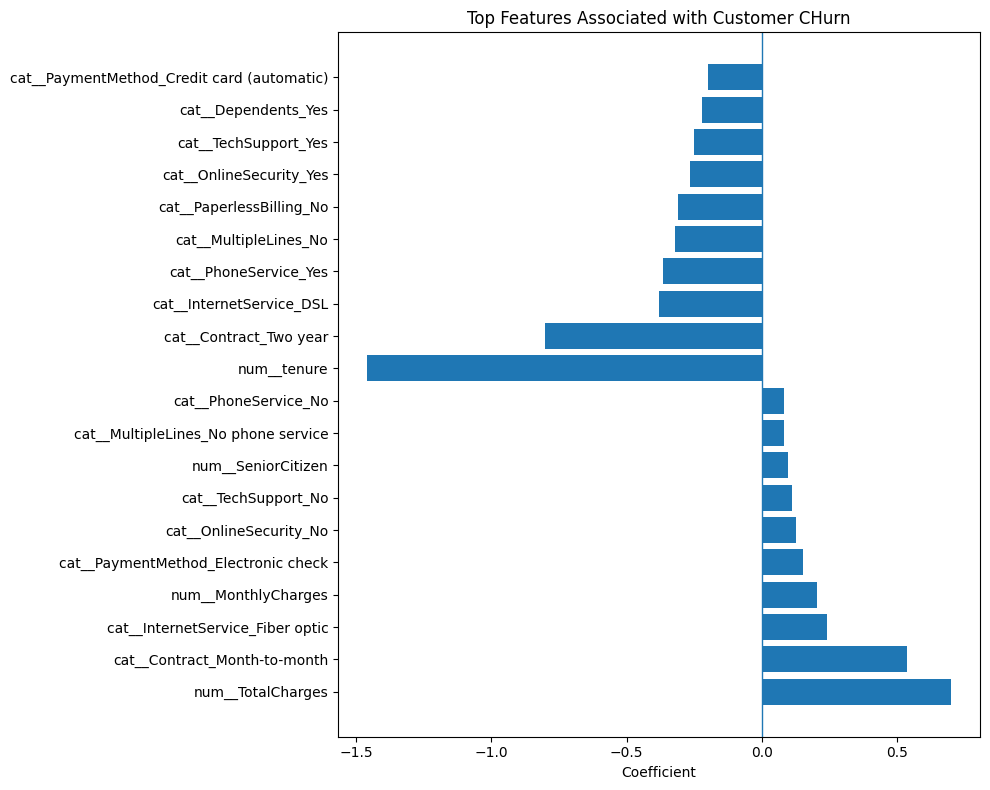

In [739]:
top_positives = coef_df.sort_values('Coefficient', ascending=False).head(10)
top_negatives = coef_df.sort_values('Coefficient', ascending=True).head(10)

plot_df = pd.concat([top_positives, top_negatives])

plt.figure(figsize=(10, 8))
plt.barh(plot_df['Feature'], plot_df['Coefficient'])
plt.xlabel('Coefficient')
plt.title('Top Features Associated with Customer CHurn')
plt.axvline(0, linewidth=1)
plt.tight_layout()
plt.show()

### ---- Saving--the--model ----

In [740]:
import joblib 
joblib.dump(best_model, 'churn_model.pkl')

['churn_model.pkl']

In [741]:
# import os 
# print(os.path.getsize('churn_model.pkl'))

In [742]:
final_threshold = 0.4
joblib.dump(final_threshold, 'threshold.pkl')

['threshold.pkl']

In [743]:
print("FINAL MODEL RESULTS")
print("--------------------")
print("Model: Logistic Regression")
print("Threshold:", final_threshold)
print("Accuracy:", accuracy_score(y_test, final_pred))
print("Precision:", precision_score(y_test, final_pred))
print("Recall:", recall_score(y_test, final_pred))
print("F1 Score:", f1_score(y_test, final_pred))
print("ROC-AUC:", roc_auc_score(y_test, best_prob))

FINAL MODEL RESULTS
--------------------
Model: Logistic Regression
Threshold: 0.4
Accuracy: 0.7913413768630234
Precision: 0.5975609756097561
Recall: 0.6550802139037433
F1 Score: 0.625
ROC-AUC: 0.856477821695213
